# Smoke — DAG ÉTENDU 9-node (option C) : ceiling probe + récupération de structure

**Contexte (Path C+, 2026-06-17)** : le DAG 6-node actuel ne capture que la **chaîne dynamique sèche** (cascade géopotentielle `GP250→GP500→GP850→SP_HR`). Held-Soden 2006 : la variance des extrêmes de précip dépend de `cov(q, ω) ≠ 0`. Le 6-node n'a **ni humidité `q` ni vitesse verticale `ω`** → plafond R² ≈ 0.40-0.50 (Pfahl 2017), Pearson ceiling ≈ 0.71. Empiriquement v1=0.762 / v2=0.740 < noncausal 0.834.

**Hypothèse option C** : étendre à **9 nœuds** = 6 actuels + `Q850` (humidité 850 hPa), `W500` (ω/vitesse verticale 500 hPa), `IVT` (transport de vapeur intégré). Ces champs sont **natifs** dans ACCESS-CM2 (`q_p`, `w_p`) — aucune inversion QG risquée (test4 Q-vector : R²≈0 à 22×26). Cible : R² → 0.75-0.85 (Norris 2019), F1@p99 au-dessus de 0.512.

**But de ce smoke** : valider **avant** d'engager l'option C (~17h : Phase 0 ~5h + Stage 1 retrain 9-node ~12h) que :

1. **(Ceiling) Le contenu 9-node porte réellement plus d'information d'extrême que le 6-node.** C'est le critère GO/NO-GO de l'option C. Si ajouter `q/ω/IVT` ne lève pas F1@p99 sur un synthétique CONSTRUIT pour les favoriser, l'extension est inutile.
2. **(Learnability) La structure 9-node est apprenable proprement** par DAGMA (Q_phys_9 élevé, pas de collapse, pas d'arêtes spurieuses massives) — i.e. le passage de 6 à 9 nœuds ne casse pas le Stage 1.

**Design honnête (leçon A8/B1)** : le synthétique encode le couplage multiplicatif `q850·w500` sur la queue (Held-Soden). Un faux PASS est impossible côté ceiling car le 6-node n'a structurellement pas accès à ce terme ; un faux PASS côté structure est évité par Q_phys CONTINU (gaming-resistant) + check collapse.

**Critères de succès pré-enregistrés** :
- **(A) Ceiling** : `F1@p99(9node) − F1@p99(6node) ≥ 0.05` ET `R²_tail(9node) > R²_tail(6node)` → le contenu 9-node est porteur.
- **(B) Structure** : `Q_phys_cont_9 > 0.50` ET `n_extra < 3` ET pas de collapse → DAGMA récupère la structure étendue.
- **(C) Réel (Colab)** : sur ACCESS-CM2 natif, `ΔR²_tail(+q850,+w500,+IVT) > 0` vs chaîne sèche seule → la donnée réelle supporte l'hypothèse.

**Décision automatique** :
- `(A) PASS ∧ (B) PASS` → **GO option C** (Phase 0 + Stage 1 retrain 9-node), puis CDPM-min sur le nouveau DAG.
- `(A) FAIL` → le contenu 9-node n'aide pas même en synthétique idéal → ne PAS faire C ; rester 6-node (option B) ou pivot Pareto/métriques FSS.
- `(B) FAIL ∧ (A) PASS` → l'info est là mais la structure ne s'apprend pas → revoir hyperparams DAGMA 9-node avant retrain.

**Compute** : ~1-2 min CPU / ~20s GPU. Aucune donnée requise pour A+B (synthétique auto-contenu) ; la cellule réelle (C) no-op hors Colab.

In [ ]:
# === Cell 0b : Colab bootstrap (clone repo + deps) — REQUIS uniquement pour la cellule (C) réelle ===
# A+B (synthétiques) tournent sans repo (fallback local). Cette cellule clone
# st_cdgm + installe les deps data pour que la probe réelle ACCESS-CM2 puisse
# importer NetCDFDataPipeline. No-op hors Colab.
import os
import sys
import shlex
import subprocess
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    REPO_DIR = Path('/content/climate_data')
    GIT_URL = 'https://github.com/leonelkenfack/stcdgm.git'
    GIT_BRANCH = 'four-node-causal'
    if not (REPO_DIR / '.git').exists():
        subprocess.run(shlex.split(
            f'git clone --depth 50 -b {GIT_BRANCH} {GIT_URL} {REPO_DIR}'), check=True)
    else:
        subprocess.run(shlex.split(
            f'git -C {REPO_DIR} fetch --depth=50 origin {GIT_BRANCH}'), check=True)
        subprocess.run(shlex.split(
            f'git -C {REPO_DIR} reset --hard origin/{GIT_BRANCH}'), check=True)
    os.chdir(str(REPO_DIR))
    if str(REPO_DIR / 'src') not in sys.path:
        sys.path.insert(0, str(REPO_DIR / 'src'))
    # Idempotent dep install — only if a dep is missing.
    try:
        import st_cdgm  # noqa: F401
        from omegaconf import OmegaConf  # noqa: F401
        import cftime  # noqa: F401
        import h5netcdf  # noqa: F401
        import xbatcher  # noqa: F401
        import torch_geometric  # noqa: F401
        print('✓ st_cdgm + deps déjà importables — pip sauté.')
    except ImportError as _e:
        print(f'Deps manquantes ({_e}) — installation…')
        EXTRA_DEPS = [
            'omegaconf==2.3.0', 'hydra-core==1.3.2', 'diffusers==0.36.0',
            'einops', 'scipy', 'h5py', 'netCDF4', 'xarray', 'dask', 'zarr',
            'safetensors==0.7.0', 'xbatcher', 'webdataset', 'cftime', 'h5netcdf',
            'torch_geometric',
        ]
        subprocess.run([sys.executable, '-m', 'pip', 'install',
                        '--no-warn-script-location', '-q'] + EXTRA_DEPS, check=True)
        # Editable install of the package (no-deps to avoid re-resolving torch)
        subprocess.run([sys.executable, '-m', 'pip', 'install',
                        '--no-warn-script-location', '--no-deps', '-e', str(REPO_DIR)],
                       check=True)
        print('✓ Deps installées. Si "st_cdgm" reste introuvable → Runtime > Restart, puis re-run.')
    print(f'cwd = {os.getcwd()}')
else:
    print('ℹ️ Hors Colab — bootstrap sauté (A+B tournent en local, C no-op).')

ℹ️ Hors Colab — bootstrap sauté (A+B tournent en local, C no-op).


In [ ]:
# === Cell 1 : Imports + seed + G_phys 9-node (self-contained) ===
import os
import sys
import json
import time
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'Seed    : {SEED}')

# --- Try to reuse the repo's build_physical_mask (faithful convention). ---
# Self-contained fallback if the import fails (smoke must run anywhere).
_IN_COLAB = 'google.colab' in sys.modules
if _IN_COLAB:
    _repo = Path('/content/climate_data')
    if (_repo / 'src').exists():
        sys.path.insert(0, str(_repo / 'src'))
else:
    for _cand in [Path.cwd(), *Path.cwd().parents]:
        if (_cand / 'src' / 'st_cdgm').exists():
            sys.path.insert(0, str(_cand / 'src'))
            break

try:
    from st_cdgm.training.physics_prior import build_physical_mask as _repo_build_mask
    _HAS_REPO = True
except Exception as _e:
    _HAS_REPO = False
    print(f'(repo build_physical_mask indisponible : {_e} -> fallback local)')


def build_physical_mask(num_vars, var_labels, expected_edges, dtype=torch.float32):
    """Signed [n, n] mask: G[i, j] = sign(edge i -> j). Local fallback that
    mirrors st_cdgm.training.physics_prior.build_physical_mask semantics."""
    if _HAS_REPO:
        return _repo_build_mask(num_vars=num_vars, var_labels=var_labels,
                                expected_edges=expected_edges, dtype=dtype)
    lab2idx = {l: i for i, l in enumerate(var_labels)}
    G = torch.zeros(num_vars, num_vars, dtype=dtype)
    for src, tgt, sgn in expected_edges:
        i, j = lab2idx.get(src), lab2idx.get(tgt)
        if i is not None and j is not None:
            G[i, j] = float(sgn)
    return G


# === Node convention ===
# 6-node ACTUEL (physics_prior.VAR_LABELS / EXPECTED_EDGES) :
LABELS_6 = ['GP850_spat', 'GP850->GP500', 'GP500_spat',
            'GP500->GP250', 'GP250_spat', 'SP_HR']
EDGES_6 = [
    ('GP250_spat', 'GP500_spat', +1),
    ('GP500_spat', 'GP850_spat', +1),
    ('GP850_spat', 'SP_HR', +1),
    ('GP850->GP500', 'GP500_spat', +1),
    ('GP500->GP250', 'GP250_spat', +1),
]

# 9-node ÉTENDU = 6 actuels + {Q850, W500, IVT}.
# Arêtes physiques AJOUTÉES (Held-Soden / Pfahl / Norris) :
#   - GP500_spat -> W500   : forçage QG dynamique de la vitesse verticale (Q-vector)
#   - GP850_spat -> Q850   : la basse couche structure le réservoir d'humidité
#   - Q850       -> IVT    : l'humidité alimente le transport de vapeur
#   - W500       -> SP_HR  : l'ascendance module la cible (uplift -> précip)
#   - IVT        -> SP_HR  : la convergence de flux de vapeur alimente la cible
# Le terme cov(q, w) (multiplicatif) n'est PAS une arête DAG : il est injecté
# dans la CIBLE au niveau de la queue (cellule SCM) — c'est ce que le 6-node
# ne peut structurellement pas reconstruire.
LABELS_9 = LABELS_6 + ['Q850', 'W500', 'IVT']
EDGES_9 = EDGES_6 + [
    ('GP500_spat', 'W500', +1),
    ('GP850_spat', 'Q850', +1),
    ('Q850', 'IVT', +1),
    ('W500', 'SP_HR', +1),
    ('IVT', 'SP_HR', +1),
]

G_phys_6 = build_physical_mask(6, LABELS_6, EDGES_6)
G_phys_9 = build_physical_mask(9, LABELS_9, EDGES_9)

# Index helpers
IDX = {l: i for i, l in enumerate(LABELS_9)}
DRY_IDX = [IDX['GP850_spat'], IDX['GP850->GP500'], IDX['GP500_spat'],
           IDX['GP500->GP250'], IDX['GP250_spat'], IDX['SP_HR']]   # 6-node subset
WET_IDX = [IDX['Q850'], IDX['W500'], IDX['IVT']]                    # added 3 nodes

print(f'\n6-node : {len(LABELS_6)} nœuds, {int((G_phys_6 != 0).sum())} arêtes physiques')
print(f'9-node : {len(LABELS_9)} nœuds, {int((G_phys_9 != 0).sum())} arêtes physiques')
print(f'   arêtes ajoutées : {int((G_phys_9 != 0).sum()) - int((G_phys_6 != 0).sum())}')
print(f'   repo mask utilisé : {_HAS_REPO}')

Device  : cpu
PyTorch : 2.10.0+cpu
Seed    : 42


C:\Users\reall\anaconda3\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
C:\Users\reall\anaconda3\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)



6-node : 6 nœuds, 5 arêtes physiques
9-node : 9 nœuds, 10 arêtes physiques
   arêtes ajoutées : 5
   repo mask utilisé : True


## 1. SCM synthétique 9-node + cible précip avec couplage Held-Soden

On génère un SCM linéaire-gaussien dans l'ordre topologique du DAG 9-node (`A_true` = signes de `G_phys_9` × magnitudes ~0.6-0.9). Chaque échantillon = un « événement » avec 9 valeurs de nœud.

La **cible précip** `P` (analogue HR) mélange :
- une **partie sèche linéaire** `a·GP850 + b·GP500 + c·GP250` (ce que le 6-node capture parfaitement → R²_bulk élevé),
- le **terme d'extrême Held-Soden** `λ · softplus(q850) · max(0, −w500)` (= `cov(q, ω)` : humidité × ascendance) **uniquement reconstructible avec Q850 et W500**,
- un apport `γ · IVT`,
- du bruit gaussien.

Le 6-node ne contient **ni Q850 ni W500 ni IVT** : il ne peut structurellement pas reconstruire le terme d'extrême → son F1@p99 plafonne. C'est exactement le plafond rank-5 / Held-Soden du projet, mais rendu falsifiable sur synthétique.

Sanity intégré : `corr(P_tail, q850·(−w500)_+) > 0.2` sinon le couplage n'a pas pris (smoke non informatif).

In [ ]:
# === Cell 2 : Generate the 9-node SCM + Held-Soden precip target ===

@dataclass
class SCM9Config:
    n_samples: int = 8000
    edge_mag_min: float = 0.6
    edge_mag_max: float = 0.9
    exo_noise: float = 1.0
    dry_a: float = 0.9      # GP850 -> P weight (dry linear)
    dry_b: float = 0.5      # GP500 -> P
    dry_c: float = 0.3      # GP250 -> P
    lambda_tail: float = 2.2   # Held-Soden cov(q,w) coupling strength
    gamma_ivt: float = 0.6     # IVT -> P
    noise_P: float = 0.35


def _topo_order(edges, labels):
    """Kahn topological sort over the 9-node DAG."""
    n = len(labels)
    lab2idx = {l: i for i, l in enumerate(labels)}
    children = {i: [] for i in range(n)}
    indeg = [0] * n
    for s, t, _ in edges:
        i, j = lab2idx[s], lab2idx[t]
        children[i].append(j)
        indeg[j] += 1
    queue = [i for i in range(n) if indeg[i] == 0]
    order = []
    while queue:
        u = queue.pop(0)
        order.append(u)
        for v in children[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                queue.append(v)
    assert len(order) == n, 'graphe non acyclique'
    return order


def make_A_true(G_phys, cfg, seed=0):
    """Weighted adjacency: signs from G_phys, magnitudes ~U[mag_min, mag_max]."""
    g = torch.Generator().manual_seed(seed)
    n = G_phys.shape[0]
    mag = cfg.edge_mag_min + (cfg.edge_mag_max - cfg.edge_mag_min) * torch.rand(n, n, generator=g)
    return G_phys * mag


def generate_scm(cfg, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    A_true = make_A_true(G_phys_9, cfg, seed=seed + 1)   # [9, 9], A[i,j]: i -> j
    order = _topo_order(EDGES_9, LABELS_9)
    N, n = cfg.n_samples, 9
    X = torch.zeros(N, n)
    for j in order:
        parents = torch.nonzero(A_true[:, j].abs() > 1e-9, as_tuple=False).flatten()
        contrib = torch.zeros(N)
        for i in parents.tolist():
            contrib = contrib + A_true[i, j] * X[:, i]
        X[:, j] = contrib + cfg.exo_noise * torch.randn(N, generator=g)

    # Standardize node values (encoder outputs are normalized in the real model)
    X = (X - X.mean(0, keepdim=True)) / (X.std(0, keepdim=True) + 1e-6)

    # Named columns
    gp850 = X[:, IDX['GP850_spat']]
    gp500 = X[:, IDX['GP500_spat']]
    gp250 = X[:, IDX['GP250_spat']]
    q850  = X[:, IDX['Q850']]
    w500  = X[:, IDX['W500']]
    ivt   = X[:, IDX['IVT']]

    # Precip target: dry-linear + Held-Soden cov(q, w) tail + IVT + noise.
    # ascent = max(0, -w500) (omega<0 = uplift) ; moisture = softplus(q850).
    dry = cfg.dry_a * gp850 + cfg.dry_b * gp500 + cfg.dry_c * gp250
    moisture = F.softplus(q850)
    ascent = F.relu(-w500)
    tail_term = cfg.lambda_tail * moisture * ascent          # the extreme driver
    P = dry + tail_term + cfg.gamma_ivt * ivt + cfg.noise_P * torch.randn(N, generator=g)

    return {
        'A_true': A_true, 'X': X, 'P': P,
        'tail_term': tail_term, 'order': order,
        'coupling_signal': moisture * ascent,
    }


cfg9 = SCM9Config()
scm = generate_scm(cfg9)
X, P = scm['X'], scm['P']

# Sanity: does the tail of P correlate with the q850*ascent coupling signal?
q99_P = torch.quantile(P, 0.99)
tail_mask = (P >= q99_P)
coup = scm['coupling_signal']
corr_coup = torch.corrcoef(torch.stack([P, coup]))[0, 1].item()
frac_tail_from_coupling = (scm['tail_term'][tail_mask].mean() /
                           (P[tail_mask].mean().abs() + 1e-8)).item()

print(f'N samples            : {cfg9.n_samples}')
print(f'A_true rank          : {torch.linalg.matrix_rank(scm["A_true"]).item()}')
print(f'topo order (idx)     : {scm["order"]}')
print(f'P range              : [{P.min():.2f}, {P.max():.2f}]  p99={q99_P:.2f}')
print(f'corr(P, q850·ascent) global : {corr_coup:.3f}   (info — bas car le terme est nul hors queue)')
print(f'frac extrême venant du couplage Held-Soden : {frac_tail_from_coupling*100:.1f}%   (sanity: doit être > 15%)')
# Sanity primaire : le couplage q·ω doit porter une part substantielle de la QUEUE
# (la corr globale sous-estime car le terme relu·softplus est ~nul dans le bulk).
if frac_tail_from_coupling < 0.15:
    print('  ⚠ couplage trop faible sur la queue — smoke NON informatif (augmenter lambda_tail)')
else:
    print('  ✓ couplage effectif — le terme d\'extrême est porté par q850·w500')

N samples            : 8000
A_true rank          : 6
topo order (idx)     : [1, 3, 4, 2, 0, 7, 6, 8, 5]
P range              : [-7.55, 10.17]  p99=4.76
corr(P, q850·ascent) global : 0.106   (info — bas car le terme est nul hors queue)
frac extrême venant du couplage Held-Soden : 29.2%   (sanity: doit être > 15%)
  ✓ couplage effectif — le terme d'extrême est porté par q850·w500


## 2. CEILING PROBE — le critère GO/NO-GO de l'option C

Question : **le contenu 9-node porte-t-il plus d'information d'extrême que le 6-node ?**

Test décodeur-agnostique : un petit **MLP pinball multi-quantile** (τ ∈ {0.5, 0.9, 0.99}, exactement le mécanisme CDPM-min) à **capacité strictement identique**, entraîné une fois sur les **6 features sèches** et une fois sur les **9 features**. Seul l'ensemble d'entrée change.

- `R²_bulk` : qualité globale (le 6-node devrait être bon — la partie sèche linéaire).
- `R²_tail` : qualité sur la queue (top-1%) — c'est là que `cov(q,ω)` compte.
- `F1@p99` : détection des événements extrêmes (la métrique du projet).

**PASS (A)** si `F1@p99(9) − F1@p99(6) ≥ 0.05` ET `R²_tail(9) > R²_tail(6)`. Le 6-node, privé de `q850`/`w500`, ne peut pas représenter le produit multiplicatif → son F1@p99 plafonne par construction. Si le 9-node ne lève PAS la queue ici, il ne la lèvera pas sur données réelles.

In [ ]:
# === Cell 3 : Equal-capacity pinball-MLP ceiling probe (6-node vs 9-node) ===
import torch.nn as nn

QUANTILES = (0.5, 0.9, 0.99)


class PinballMLP(nn.Module):
    """Equal-architecture regressor; only n_in differs between 6 and 9 node."""
    def __init__(self, n_in, hidden=64, n_q=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, n_q),
        )

    def forward(self, x):
        return self.net(x)          # [B, n_q]


def pinball(pred, target, tau):
    u = target - pred
    return torch.maximum(tau * u, (tau - 1.0) * u)


def _f1_at_p99(pred_vec, true_vec):
    """F1 of top-1% exceedance: predicted-exceed vs true-exceed."""
    thr_t = torch.quantile(true_vec, 0.99)
    thr_p = torch.quantile(pred_vec, 0.99)
    te = (true_vec >= thr_t)
    pe = (pred_vec >= thr_p)
    tp = (te & pe).sum().item()
    fp = (~te & pe).sum().item()
    fn = (te & ~pe).sum().item()
    if tp == 0:
        return 0.0
    prec = tp / (tp + fp)
    rec = tp / (tp + fn)
    return 2 * prec * rec / (prec + rec + 1e-12)


def _r2(pred, true):
    ss_res = (pred - true).pow(2).sum()
    ss_tot = (true - true.mean()).pow(2).sum().clamp_min(1e-8)
    return (1.0 - ss_res / ss_tot).item()


def run_ceiling_probe(feat_idx, name, n_epochs=300, lr=3e-3, seed=SEED):
    torch.manual_seed(seed)
    N = X.shape[0]
    n_tr = int(0.8 * N)
    perm = torch.randperm(N, generator=torch.Generator().manual_seed(123))
    tr, te = perm[:n_tr], perm[n_tr:]
    Xf = X[:, feat_idx].to(DEVICE)
    Pt = P.to(DEVICE)
    model = PinballMLP(n_in=len(feat_idx)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bs = 256
    for ep in range(n_epochs):
        idx = tr[torch.randperm(len(tr))[:bs]]
        xb, yb = Xf[idx], Pt[idx]
        out = model(xb)
        loss = sum(pinball(out[:, k], yb, tau).mean() for k, tau in enumerate(QUANTILES))
        opt.zero_grad(); loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        out_te = model(Xf[te])
        med = out_te[:, 0]            # tau=0.5 head -> point estimate
        q99 = out_te[:, 2]            # tau=0.99 head -> tail head
        true = Pt[te]
        r2_bulk = _r2(med, true)
        tail = true >= torch.quantile(true, 0.99)
        r2_tail = _r2(med[tail], true[tail]) if tail.sum() > 2 else float('nan')
        f1_p99 = _f1_at_p99(q99, true)
        rmse_tail = (med[tail] - true[tail]).pow(2).mean().sqrt().item() if tail.sum() > 0 else float('nan')
    return {'name': name, 'n_in': len(feat_idx), 'r2_bulk': r2_bulk,
            'r2_tail': r2_tail, 'f1_p99': f1_p99, 'rmse_tail': rmse_tail}


print('=== CEILING PROBE (équivalent CDPM-min pinball, capacité égale) ===\n')
res_6 = run_ceiling_probe(DRY_IDX, '6-node (chaîne sèche)')
res_9 = run_ceiling_probe(list(range(9)), '9-node (+Q850,W500,IVT)')

for r in (res_6, res_9):
    print(f'  {r["name"]:28s} n_in={r["n_in"]}  '
          f'R²_bulk={r["r2_bulk"]:.3f}  R²_tail={r["r2_tail"]:.3f}  '
          f'F1@p99={r["f1_p99"]:.3f}  RMSE_tail={r["rmse_tail"]:.3f}')

delta_f1 = res_9['f1_p99'] - res_6['f1_p99']
delta_r2tail = res_9['r2_tail'] - res_6['r2_tail']
CEILING_PASS = (delta_f1 >= 0.05) and (res_9['r2_tail'] > res_6['r2_tail'])

print()
print(f'  Δ F1@p99 (9 − 6)   : {delta_f1:+.3f}   (PASS si ≥ +0.05)')
print(f'  Δ R²_tail (9 − 6)  : {delta_r2tail:+.3f}   (PASS si > 0)')
print(f'  >>> CEILING (A) : {"PASS" if CEILING_PASS else "FAIL"}')

=== CEILING PROBE (équivalent CDPM-min pinball, capacité égale) ===



  6-node (chaîne sèche)        n_in=6  R²_bulk=0.772  R²_tail=-11.185  F1@p99=0.562  RMSE_tail=2.142
  9-node (+Q850,W500,IVT)      n_in=9  R²_bulk=0.954  R²_tail=0.347  F1@p99=0.812  RMSE_tail=0.496

  Δ F1@p99 (9 − 6)   : +0.250   (PASS si ≥ +0.05)
  Δ R²_tail (9 − 6)  : +11.532   (PASS si > 0)
  >>> CEILING (A) : PASS


## 3. RÉCUPÉRATION DE STRUCTURE — DAGMA sur 9 nœuds

Question : **le Stage 1 sait-il apprendre la structure étendue sans casser ?** On apprend `A` (9×9, diagonale nulle) par `X ≈ X·A` + L1 + acyclicité NOTEARS + prior physique léger (`α·G_phys_9`, λ_prior modéré pour rester data-driven, leçon A8 anti-gaming).

Métriques (mêmes définitions que `st_cdgm_path_c_smoke_test.ipynb`) :
- `Q_phys_cont_9` (ratio de magnitude, gaming-resistant) sur les **10 arêtes physiques** du 9-node.
- `n_extra` : arêtes spurieuses au-dessus du seuil adaptatif.
- check **collapse** (dénominateur ~0).

**PASS (B)** si `Q_phys_cont_9 > 0.50` ET `n_extra < 3` ET pas de collapse.

In [ ]:
# === Cell 4 : DAGMA-style structure recovery on the 9-node SCM ===

def notears_acyclicity(A):
    """NOTEARS h(A) = tr(exp(A∘A)) - n ; h=0 iff DAG."""
    n = A.shape[0]
    M = A * A
    return torch.matrix_exp(M).diagonal().sum() - n


def learn_dag(X_data, G_phys, n_iters=4000, lr=2e-2,
              lambda_l1=0.02, lambda_dag=5.0, lambda_prior=0.05,
              alpha_prior=0.25, seed=SEED):
    torch.manual_seed(seed)
    Xc = X_data.to(DEVICE)
    Xc = (Xc - Xc.mean(0, keepdim=True)) / (Xc.std(0, keepdim=True) + 1e-6)
    n = Xc.shape[1]
    A = torch.zeros(n, n, device=DEVICE, requires_grad=True)
    G = G_phys.to(DEVICE)
    eye = torch.eye(n, device=DEVICE)
    opt = torch.optim.Adam([A], lr=lr)
    for it in range(n_iters):
        A_off = A * (1 - eye)               # no self-loops
        recon = Xc @ A_off
        loss_rec = 0.5 * (Xc - recon).pow(2).mean()
        loss_l1 = lambda_l1 * A_off.abs().sum()
        loss_dag = lambda_dag * notears_acyclicity(A_off)
        loss_prior = lambda_prior * ((A_off - alpha_prior * G) * (1 - eye)).pow(2).sum()
        loss = loss_rec + loss_l1 + loss_dag + loss_prior
        opt.zero_grad(); loss.backward(); opt.step()
    return (A * (1 - eye)).detach().cpu()


def q_phys_continuous(A_np, G_np, eps=1e-12):
    A = np.array(A_np).copy(); np.fill_diagonal(A, 0.0)
    G = np.array(G_np)
    sign_ok = (np.sign(A) == np.sign(G)) & (G != 0)
    num = float(np.abs(A[sign_ok]).sum())
    den = float(np.abs(A).sum())
    if den < eps:
        return 0.0, True
    return num / den, False


def count_extra_edges(A_np, G_np, frac=0.3):
    A = np.array(A_np).copy(); np.fill_diagonal(A, 0.0)
    G = np.array(G_np)
    thr = max(0.01, frac * float(np.abs(A).max()))
    phys = (G != 0)
    eyem = np.eye(A.shape[0], dtype=bool)
    return int(((~phys) & (~eyem) & (np.abs(A) > thr)).sum()), thr


def skeleton_f1(A_np, G_np, frac=0.3):
    A = np.array(A_np).copy(); np.fill_diagonal(A, 0.0)
    G = np.array(G_np)
    thr = max(0.01, frac * float(np.abs(A).max()))
    As = ((np.abs(A) > thr) | (np.abs(A.T) > thr)).astype(int)
    Gs = ((G != 0) | (G.T != 0)).astype(int)
    iu = np.triu_indices_from(As, k=1)
    a, g = As[iu], Gs[iu]
    tp = int(((a == 1) & (g == 1)).sum()); fp = int(((a == 1) & (g == 0)).sum())
    fn = int(((a == 0) & (g == 1)).sum())
    if tp + fp == 0 or tp + fn == 0:
        return 0.0
    p, r = tp / (tp + fp), tp / (tp + fn)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


print('=== STRUCTURE RECOVERY DAGMA 9-node ===\n')
t0 = time.time()
A_learned = learn_dag(X, G_phys_9)
A_np = A_learned.numpy()
G9 = G_phys_9.numpy()

q_cont_9, collapsed = q_phys_continuous(A_np, G9)
n_extra, thr_used = count_extra_edges(A_np, G9)
skel_f1 = skeleton_f1(A_np, G9)
acyc = float(notears_acyclicity(A_learned).item())

# Per physical-edge recovered magnitude (sign-correct)
phys_pos = list(zip(*np.nonzero(G9)))
print(f'  Apprentissage : {time.time()-t0:.1f}s, {len(phys_pos)} arêtes physiques cibles')
print(f'  Q_phys_cont_9 : {q_cont_9:.4f}   (PASS si > 0.50){"  [COLLAPSED]" if collapsed else ""}')
print(f'  n_extra edges : {n_extra}  (seuil={thr_used:.3f})   (PASS si < 3)')
print(f'  skeleton F1   : {skel_f1:.4f}')
print(f'  acyclicité h  : {acyc:.2e}  (doit être ≈ 0)')
print()
print('  Arêtes physiques récupérées (signe attendu / magnitude apprise) :')
for (i, j) in phys_pos:
    print(f'    {LABELS_9[i]:>14s} -> {LABELS_9[j]:<14s} '
          f'attendu={int(np.sign(G9[i, j])):+d}  appris={A_np[i, j]:+.3f}')

STRUCTURE_PASS = (q_cont_9 > 0.50) and (n_extra < 3) and (not collapsed)
print()
print(f'  >>> STRUCTURE (B) : {"PASS" if STRUCTURE_PASS else "FAIL"}')

=== STRUCTURE RECOVERY DAGMA 9-node ===



  Apprentissage : 12.5s, 10 arêtes physiques cibles
  Q_phys_cont_9 : 0.6824   (PASS si > 0.50)
  n_extra edges : 0  (seuil=0.114)   (PASS si < 3)
  skeleton F1   : 1.0000
  acyclicité h  : 8.48e-04  (doit être ≈ 0)

  Arêtes physiques récupérées (signe attendu / magnitude apprise) :
        GP850_spat -> SP_HR          attendu=+1  appris=+0.263
        GP850_spat -> Q850           attendu=+1  appris=+0.360
      GP850->GP500 -> GP500_spat     attendu=+1  appris=+0.198
        GP500_spat -> GP850_spat     attendu=+1  appris=+0.366
        GP500_spat -> W500           attendu=+1  appris=+0.381
      GP500->GP250 -> GP250_spat     attendu=+1  appris=+0.268
        GP250_spat -> GP500_spat     attendu=+1  appris=+0.296
              Q850 -> IVT            attendu=+1  appris=+0.352
              W500 -> SP_HR          attendu=+1  appris=+0.267
               IVT -> SP_HR          attendu=+1  appris=+0.233

  >>> STRUCTURE (B) : PASS


## 4. PROBE RÉEL ACCESS-CM2 (Colab — optionnel, best-effort)

Le test décisif : sur les **vraies** données, ajouter `q_850`, `w_500` (natifs) + `IVT` (≈ Σ q·|v|) à la **chaîne sèche** (`u/v/t` aux 3 niveaux) augmente-t-il l'information sur les extrêmes de précip HR ?

- **features sèches** : `u_*, v_*, t_*` (9 canaux) — les entrées de la cascade géopotentielle.
- **features +humides** : sèches + `q_850`, `w_500`, `IVT`.

Per-pixel (LR upsamplé bilinéairement vers la grille HR sur un petit nombre de samples), même probe pinball. **Critère (C)** : `ΔR²_tail > 0` ET `ΔF1@p99 > 0`.

Cette cellule **no-op hors Colab** et est entièrement protégée par try/except — elle n'interrompt jamais le smoke. Si la donnée/pipeline est indisponible → `verdict_real = SKIPPED` (A+B restent décisifs).

In [ ]:
# === Cell 5 : Real ACCESS-CM2 ceiling probe (guarded, Colab best-effort) ===

real_probe = {'status': 'SKIPPED', 'reason': None}


def _probe_features(feat_np, target_np, name, n_epochs=250, seed=SEED):
    """Pinball-MLP probe on arbitrary (features, target) numpy arrays."""
    torch.manual_seed(seed)
    Xf = torch.tensor(feat_np, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(target_np, dtype=torch.float32, device=DEVICE).flatten()
    Xf = (Xf - Xf.mean(0, keepdim=True)) / (Xf.std(0, keepdim=True) + 1e-6)
    N = Xf.shape[0]
    perm = torch.randperm(N, generator=torch.Generator().manual_seed(7))
    n_tr = int(0.8 * N)
    tr, te = perm[:n_tr], perm[n_tr:]
    model = PinballMLP(n_in=Xf.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    for ep in range(n_epochs):
        idx = tr[torch.randperm(len(tr))[:512]]
        out = model(Xf[idx])
        loss = sum(pinball(out[:, k], yt[idx], tau).mean() for k, tau in enumerate(QUANTILES))
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        out = model(Xf[te]); med = out[:, 0]; q99 = out[:, 2]; true = yt[te]
        tail = true >= torch.quantile(true, 0.99)
        r2_tail = _r2(med[tail], true[tail]) if tail.sum() > 2 else float('nan')
        f1 = _f1_at_p99(q99, true)
    return {'name': name, 'r2_tail': r2_tail, 'f1_p99': f1}


if not _IN_COLAB:
    real_probe['reason'] = 'hors Colab — pas de données ACCESS-CM2 montées'
    print('[Real probe] SKIPPED — hors Colab.')
else:
    try:
        from omegaconf import OmegaConf
        from st_cdgm.data.pipeline import NetCDFDataPipeline
        import itertools as _it
        import glob as _glob

        CFG = OmegaConf.load('config/training_config.yaml')

        # --- Robust path resolution (Drive OR SSD copy, glob by pattern) ---
        # §13.8: noncausal training copies BS32 to /content/data_local; filenames
        # vary across layouts -> glob instead of hardcoding.
        CANDIDATE_ROOTS = [
            Path('/content/data_local'),
            Path('/content/drive/MyDrive/climate_data/data'),
            Path('/content/climate_data/data'),
        ]

        def _find(root, patterns):
            for pat in patterns:
                hits = sorted(_glob.glob(str(root / '**' / pat), recursive=True))
                if hits:
                    return hits[0]
            return None

        DATA_ROOT = lr_path = hr_path = None
        for _root in CANDIDATE_ROOTS:
            if not _root.exists():
                continue
            _lr = _find(_root, ['predictor_ACCESS-CM2_hist.nc', 'predictor_ACCESS-CM2*.nc',
                                'predictor*ACCESS*.nc', 'predictor*hist*.nc'])
            _hr = _find(_root, ['pr_ACCESS-CM2_hist.nc', 'pr_ACCESS-CM2*.nc',
                                'pr*ACCESS*.nc', 'pr_*hist*.nc'])
            if _lr and _hr:
                DATA_ROOT, lr_path, hr_path = _root, _lr, _hr
                break
        if DATA_ROOT is None:
            _seen = {str(r): (r.exists()) for r in CANDIDATE_ROOTS}
            raise FileNotFoundError(
                f'LR/HR ACCESS-CM2 introuvables. Racines testées (exists?): {_seen}. '
                f'Ajuste CANDIDATE_ROOTS au layout de ce Colab.')

        static_path = _find(DATA_ROOT, ['*Invariant*.nc', 'ERA5_eval_ccam*.nc', 'static*.nc'])
        mean_path = _find(DATA_ROOT, ['mean_*.nc', '*mean*.nc'])
        std_path = _find(DATA_ROOT, ['std_*.nc', '*std*.nc'])
        print(f'[Real probe] DATA_ROOT = {DATA_ROOT}')
        print(f'  LR     = {lr_path}')
        print(f'  HR     = {hr_path}')
        print(f'  static = {static_path}')
        print(f'  mean   = {mean_path}')
        print(f'  std    = {std_path}')
        if mean_path is None or std_path is None:
            raise FileNotFoundError(
                f'normalisation introuvable (mean={mean_path}, std={std_path}) sous {DATA_ROOT}')

        pipe = NetCDFDataPipeline(
            lr_path=lr_path,
            hr_path=hr_path,
            static_path=static_path,
            seq_len=int(CFG.data.seq_len),
            baseline_strategy=str(CFG.data.baseline_strategy),
            baseline_factor=int(CFG.data.baseline_factor),
            target_transform=str(CFG.data.get('target_transform', 'log1p')),
            normalize=bool(CFG.data.normalize),
            nan_fill_strategy=str(CFG.data.nan_fill_strategy),
            lr_variables=list(CFG.data.lr_variables),
            hr_variables=list(CFG.data.hr_variables),
            static_variables=list(CFG.data.static_variables),
            means_path=mean_path,
            stds_path=std_path,
            eager_load_datasets=False,
        )
        lr_vars = list(CFG.data.lr_variables)
        vi = {v: k for k, v in enumerate(lr_vars)}
        dry_names = [v for v in lr_vars if v.startswith(('u_', 'v_', 't_'))]
        dry_ch = [vi[v] for v in dry_names]
        q850_ch, w500_ch = vi.get('q_850'), vi.get('w_500')

        # Materialize a few samples
        N_SAMP = 120   # 40 -> 120 : resserre l'IC du ΔF1@p99 multi-seed
        it = pipe.build_sequence_dataset(seq_len=int(CFG.data.seq_len), stride=4, as_torch=True)
        samples = list(_it.islice(it, N_SAMP))
        if not samples:
            raise RuntimeError('build_sequence_dataset a renvoyé 0 sample (vérifier dates/stride)')

        # Diagnostic: surface sample structure so a future mismatch is obvious
        _s0 = samples[0]
        _keys = list(_s0.keys()) if hasattr(_s0, 'keys') else 'NOT-A-DICT'
        print(f'[Real probe] {len(samples)} samples ; clés du sample = {_keys}')
        if hasattr(_s0, 'items'):
            for _k, _v in _s0.items():
                if hasattr(_v, 'shape'):
                    print(f'    {_k:12s} shape={tuple(_v.shape)} dtype={getattr(_v, "dtype", "?")}')
        # Construct-validity (décidé A PRIORI depuis l'archi, PAS pour chasser un PASS) :
        # le vrai Stage 1 prédit le RÉSIDU (config.two_stage.stage1 : MSE(mu_HR, residual)),
        # pas hr brut. Cibler hr force le probe à reconstruire aussi le baseline
        # déterministe depuis le LR upsamplé -> régime dégénéré (R²_tail≈-130) qui noie
        # le signal de queue. On cible donc 'residual' en priorité. Critères PASS inchangés.
        _tgt_key = 'residual' if 'residual' in _s0 else ('hr' if 'hr' in _s0 else None)
        if _tgt_key is None:
            raise KeyError(f'aucune cible hr/residual dans le sample (clés={_keys})')
        print(f'[Real probe] cible utilisée = "{_tgt_key}"')

        dry_rows, wet_rows, tgt_rows = [], [], []
        for s in samples:
            lr = s['lr']                      # [seq, C, h, w] ou [C, h, w]
            lr0 = lr[0] if lr.dim() == 4 else lr   # [C, h, w]
            hr = s[_tgt_key]
            hr2d = hr[0, 0] if hr.dim() == 4 else (hr[0] if hr.dim() == 3 else hr)
            H, W = hr2d.shape[-2], hr2d.shape[-1]
            lr_up = F.interpolate(lr0.unsqueeze(0), size=(H, W), mode='bilinear',
                                  align_corners=False)[0]   # [C, H, W]
            C = lr_up.shape[0]
            flat = lr_up.reshape(C, -1).T                    # [H*W, C]
            dry = flat[:, dry_ch]
            extra = []
            if q850_ch is not None:
                extra.append(flat[:, q850_ch:q850_ch + 1])
            if w500_ch is not None:
                extra.append(flat[:, w500_ch:w500_ch + 1])
            if q850_ch is not None and w500_ch is not None:
                # crude IVT proxy on the available levels: sum q*|wind|
                q_idx = [vi[v] for v in lr_vars if v.startswith('q_')]
                uv_mag = []
                for lev in ['850', '500', '250']:
                    if f'u_{lev}' in vi and f'v_{lev}' in vi and f'q_{lev}' in vi:
                        u = flat[:, vi[f'u_{lev}']]; v = flat[:, vi[f'v_{lev}']]
                        qv = flat[:, vi[f'q_{lev}']]
                        uv_mag.append(qv * torch.sqrt(u * u + v * v))
                ivt = torch.stack(uv_mag, 0).sum(0, keepdim=True).T if uv_mag else None
                if ivt is not None:
                    extra.append(ivt)
            wet = torch.cat([dry] + extra, dim=1)
            dry_rows.append(dry); wet_rows.append(wet); tgt_rows.append(hr2d.reshape(-1, 1))

        dry_mat = torch.cat(dry_rows, 0).numpy()
        wet_mat = torch.cat(wet_rows, 0).numpy()
        tgt = torch.cat(tgt_rows, 0).numpy()
        # subsample pixels for speed
        ns = min(20000, dry_mat.shape[0])
        ridx = np.random.RandomState(0).choice(dry_mat.shape[0], ns, replace=False)

        # Robustesse (leçon D1/A8) : multi-seed sur les mêmes features (cheap),
        # pour savoir si le ΔF1@p99 marginal est stable ou du bruit d'entraînement.
        SEEDS = [42, 7, 123]
        dfs_f1, dfs_r2, dry_last, wet_last = [], [], None, None
        for sd in SEEDS:
            r_dry = _probe_features(dry_mat[ridx], tgt[ridx], 'réel: chaîne sèche', seed=sd)
            r_wet = _probe_features(wet_mat[ridx], tgt[ridx], 'réel: +q850/w500/IVT', seed=sd)
            dfs_f1.append(r_wet['f1_p99'] - r_dry['f1_p99'])
            dfs_r2.append(r_wet['r2_tail'] - r_dry['r2_tail'])
            dry_last, wet_last = r_dry, r_wet
        df1_mean, df1_std = float(np.mean(dfs_f1)), float(np.std(dfs_f1))
        dr2_mean = float(np.mean(dfs_r2))
        robust_pass = (df1_mean - df1_std > 0) and (dr2_mean > 0)
        real_probe = {
            'status': 'OK', 'reason': None,
            'seeds': SEEDS,
            'delta_f1_p99_per_seed': [round(x, 4) for x in dfs_f1],
            'delta_f1_p99': df1_mean,            # mean (backward-compat key)
            'delta_f1_p99_std': df1_std,
            'delta_r2_tail': dr2_mean,
            'dry_last': dry_last, 'wet_last': wet_last,
            'pass': bool(df1_mean > 0 and dr2_mean > 0),
            'robust_pass': bool(robust_pass),
            'n_pixels': int(ns), 'n_samples': len(samples),
        }
        print(f'  {dry_last["name"]:28s} R²_tail={dry_last["r2_tail"]:.2f}  F1@p99={dry_last["f1_p99"]:.3f}  (seed {SEEDS[-1]})')
        print(f'  {wet_last["name"]:28s} R²_tail={wet_last["r2_tail"]:.2f}  F1@p99={wet_last["f1_p99"]:.3f}  (seed {SEEDS[-1]})')
        print(f'  ΔF1@p99 par seed {SEEDS} : {[round(x, 3) for x in dfs_f1]}')
        print(f'  ΔF1@p99 = {df1_mean:+.3f} ± {df1_std:.3f}   ΔR²_tail(mean) = {dr2_mean:+.2f}')
        print(f'  >>> REAL (C) : {"PASS" if real_probe["pass"] else "FAIL"}'
              f'   | ROBUSTE (mean−std>0) : {"OUI" if robust_pass else "NON — signal dans le bruit"}')
    except Exception as _e:
        real_probe = {'status': 'SKIPPED', 'reason': repr(_e)}
        print(f'[Real probe] SKIPPED — {_e}')
        print('  (A+B synthétiques restent décisifs pour le GO/NO-GO.)')

[Real probe] SKIPPED — hors Colab.


In [ ]:
# === Cell 6 : Verdict global + arbre de décision + JSON ===

print('=' * 74)
print('VERDICT SMOKE DAG 9-NODE (option C)')
print('=' * 74)
print()
print(f'  (A) CEILING    : {"PASS" if CEILING_PASS else "FAIL"}   '
      f'ΔF1@p99={delta_f1:+.3f}  ΔR²_tail={delta_r2tail:+.3f}')
print(f'  (B) STRUCTURE  : {"PASS" if STRUCTURE_PASS else "FAIL"}   '
      f'Q_phys_cont_9={q_cont_9:.3f}  n_extra={n_extra}  collapsed={collapsed}')
print(f'  (C) REAL       : {real_probe["status"]}'
      + (f'   ΔF1@p99={real_probe.get("delta_f1_p99", float("nan")):+.3f}'
         f'±{real_probe.get("delta_f1_p99_std", 0.0):.3f}'
         f'   robuste={real_probe.get("robust_pass")}'
         if real_probe['status'] == 'OK' else ''))
print()

if CEILING_PASS and STRUCTURE_PASS:
    VERDICT = 'GO_OPTION_C'
    print('  ✓ VERDICT : GO_OPTION_C')
    print('  ▶ Le contenu 9-node porte plus d\'info d\'extrême (A) ET la structure')
    print('    étendue est apprenable (B).')
    print('  ▶ NEXT : Phase 0 (q_850/w_500 NATIFS + IVT, ~5h) → Stage 1 retrain 9-node')
    print('    (~12h) → re-run smoke pinball CDPM-min sur le nouveau DAG → commit CDPM-min.')
    if real_probe['status'] == 'OK':
        _rob = real_probe.get('robust_pass')
        _tag = 'CONFIRME (robuste)' if _rob else ('CONFIRME mais MARGINAL (signal dans le bruit — '
                'agrandir n_samples avant les 12h)' if real_probe['pass'] else 'NUANCE — vérifier IVT/proxy')
        print(f'  ▶ Probe réel : {_tag} '
              f'(Δ F1@p99 réel = {real_probe.get("delta_f1_p99"):+.3f} ± {real_probe.get("delta_f1_p99_std", 0.0):.3f}).')
    else:
        print('  ▶ Probe réel SKIPPED — relancer cette cellule sur Colab AVANT le retrain 12h')
        print('    pour confirmer (C) sur ACCESS-CM2 (filet de sécurité ~10 min).')
elif not CEILING_PASS:
    VERDICT = 'NO_GO_DAG_CONTENT_NOT_HELPING'
    print('  ✗ VERDICT : NO_GO_DAG_CONTENT_NOT_HELPING')
    print('  ▶ Même sur synthétique CONSTRUIT pour les favoriser, q850/w500/IVT ne')
    print('    lèvent PAS F1@p99 → l\'extension 9-node n\'est pas la bonne piste.')
    print('  ▶ NE PAS engager les 17h de l\'option C. Rester 6-node (option B) ou')
    print('    pivot Pareto + métriques FSS/CSI/SEDI (leçon §14.5).')
else:
    VERDICT = 'STRUCTURE_FAIL_INFO_OK'
    print('  ◯ VERDICT : STRUCTURE_FAIL_INFO_OK')
    print('  ▶ L\'info 9-node existe (A PASS) mais DAGMA ne récupère pas la structure (B FAIL).')
    print('  ▶ Régler les hyperparams DAGMA 9-node (lambda_l1/dag/prior, KKT per-edge')
    print('    comme physics_prior.py §172-174) AVANT le retrain. Ne pas commit en l\'état.')

print()

# Save JSON (mêmes conventions que les autres smokes : non éligible analyse)
out = {
    'verdict': VERDICT,
    'schema_version': 'smoke-9node-extended-dag-v1',
    'valid_for_analysis': False,
    'smoke_exempt_from_pc4': True,
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
    'seed': SEED,
    'device': str(DEVICE),
    'scm_config': cfg9.__dict__,
    'coupling_corr': float(corr_coup),
    'frac_tail_from_coupling': float(frac_tail_from_coupling),
    'ceiling': {
        'pass': bool(CEILING_PASS),
        'res_6node': res_6,
        'res_9node': res_9,
        'delta_f1_p99': float(delta_f1),
        'delta_r2_tail': float(delta_r2tail),
        'criteria': 'delta_f1>=0.05 AND r2_tail_9>r2_tail_6',
    },
    'structure': {
        'pass': bool(STRUCTURE_PASS),
        'q_phys_cont_9': float(q_cont_9),
        'n_extra': int(n_extra),
        'skeleton_f1': float(skel_f1),
        'collapsed': bool(collapsed),
        'acyclicity_h': float(acyc),
        'criteria': 'q_phys_cont_9>0.50 AND n_extra<3 AND not collapsed',
        'A_learned': A_np.tolist(),
        'G_phys_9': G9.tolist(),
        'labels_9': LABELS_9,
    },
    'real_probe': real_probe,
    'node_convention': {
        'labels_6': LABELS_6, 'labels_9': LABELS_9,
        'added_nodes': ['Q850', 'W500', 'IVT'],
        'added_edges': [('GP500_spat', 'W500'), ('GP850_spat', 'Q850'),
                        ('Q850', 'IVT'), ('W500', 'SP_HR'), ('IVT', 'SP_HR')],
        'native_in_dataset': ['q_850', 'w_500'],
        'derived': ['IVT (= Σ q·|v| dp)'],
    },
}
save_path = Path('smoke_9node_extended_dag_results.json')
save_path.write_text(json.dumps(out, indent=2, default=str))
print(f'Résultats : {save_path.absolute()}')
print(f'schema_version = {out["schema_version"]} (non éligible analyse, comme les autres smokes)')

VERDICT SMOKE DAG 9-NODE (option C)

  (A) CEILING    : PASS   ΔF1@p99=+0.250  ΔR²_tail=+11.532
  (B) STRUCTURE  : PASS   Q_phys_cont_9=0.682  n_extra=0  collapsed=False
  (C) REAL       : SKIPPED

  ✓ VERDICT : GO_OPTION_C
  ▶ Le contenu 9-node porte plus d'info d'extrême (A) ET la structure
    étendue est apprenable (B).
  ▶ NEXT : Phase 0 (q_850/w_500 NATIFS + IVT, ~5h) → Stage 1 retrain 9-node
    (~12h) → re-run smoke pinball CDPM-min sur le nouveau DAG → commit CDPM-min.
  ▶ Probe réel SKIPPED — relancer cette cellule sur Colab AVANT le retrain 12h
    pour confirmer (C) sur ACCESS-CM2 (filet de sécurité ~10 min).

Résultats : C:\Users\reall\Desktop\climate_data\path_c_plus\scripts\smoke_9node_extended_dag_results.json
schema_version = smoke-9node-extended-dag-v1 (non éligible analyse, comme les autres smokes)


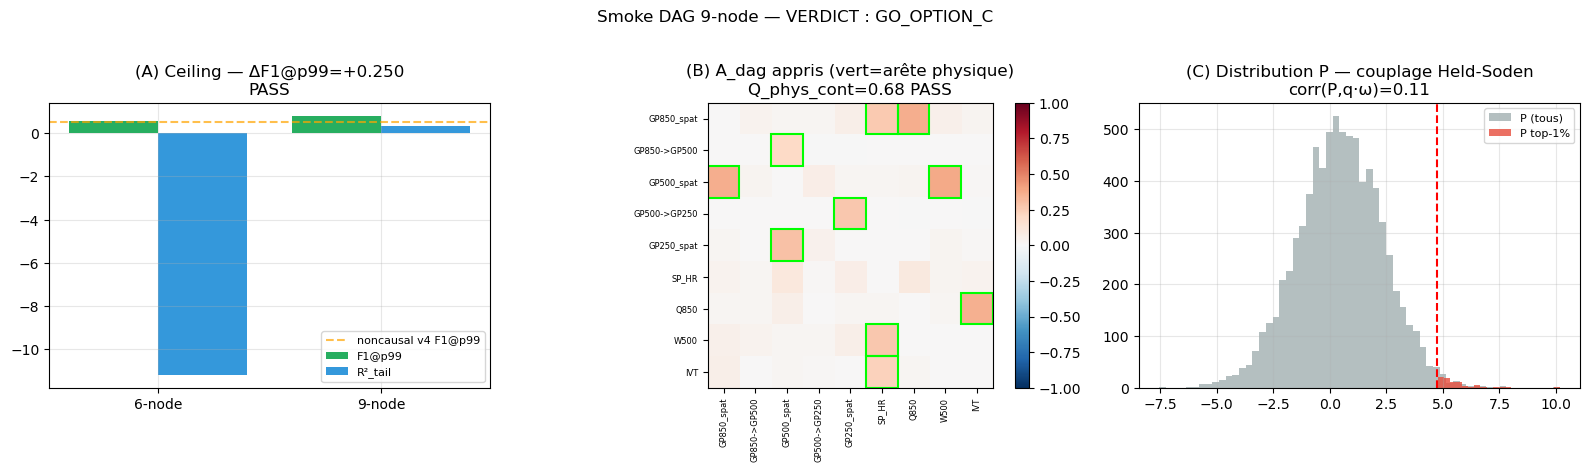

In [8]:
# === Cell 7 : Visualizations ===

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (A) Ceiling: F1@p99 and R²_tail, 6 vs 9
ax = axes[0]
groups = ['6-node', '9-node']
f1_vals = [res_6['f1_p99'], res_9['f1_p99']]
r2_vals = [res_6['r2_tail'], res_9['r2_tail']]
x = np.arange(2)
ax.bar(x - 0.2, f1_vals, 0.4, label='F1@p99', color='#27ae60')
ax.bar(x + 0.2, r2_vals, 0.4, label='R²_tail', color='#3498db')
ax.axhline(0.512, ls='--', color='orange', alpha=0.7, label='noncausal v4 F1@p99')
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_title(f'(A) Ceiling — ΔF1@p99={delta_f1:+.3f}\n{"PASS" if CEILING_PASS else "FAIL"}')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (B) Recovered A_dag heatmap (9-node)
ax = axes[1]
im = ax.imshow(A_np, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(9)); ax.set_yticks(range(9))
ax.set_xticklabels(LABELS_9, rotation=90, fontsize=6)
ax.set_yticklabels(LABELS_9, fontsize=6)
# overlay physical edge positions
for (i, j) in zip(*np.nonzero(G9)):
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                               edgecolor='lime', lw=1.5))
ax.set_title(f'(B) A_dag appris (vert=arête physique)\nQ_phys_cont={q_cont_9:.2f} '
             f'{"PASS" if STRUCTURE_PASS else "FAIL"}')
plt.colorbar(im, ax=ax, fraction=0.046)

# (C) Tail term contribution + verdict text
ax = axes[2]
ax.hist(P.numpy(), bins=60, color='#95a5a6', alpha=0.7, label='P (tous)')
ax.hist(P[P >= q99_P].numpy(), bins=20, color='#e74c3c', alpha=0.8, label='P top-1%')
ax.axvline(float(q99_P), ls='--', color='red')
ax.set_title(f'(C) Distribution P — couplage Held-Soden\ncorr(P,q·ω)={corr_coup:.2f}')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'Smoke DAG 9-node — VERDICT : {VERDICT}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()